In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import controller as ctr
import electrolyser as elec
import unclaimed_power_planing as upp

In [2]:
def simulate_episode(plant, controller, reference_signal_generator, time_step, steps_number):
    # log simulation data
    data_on_each_step = {
        "plant_state": [],
        "electrolyser_output_value": [],
        "reference_signal_plan": [],
        "reference_signal_plan_first_value": [],
        "control_signal": []
    }
    for k in range(steps_number):
        # TODO add averaging
        # get signals on step
        plant_state = plant.get_state_on_step()
        reference_signal_plan = \
            reference_signal_generator.generate_unclaimed_power_plan_on_step_from_history(k,
                                                                                          time_step)
        reference_signal_plan_first_value = reference_signal_plan[0]

        # control_signal = controller.form_control_signal(plant_state, reference_signal_plan)
        control_signal = controller.form_control_signal_energy_based(plant_state,
                                                                     reference_signal_plan)

        # log simulation data
        # data_on_each_step["plant_state"].append(plant_state)
        electrolyser_output_value = plant_state["power"]
        data_on_each_step["electrolyser_output_value"].append(electrolyser_output_value)
        # data_on_each_step["reference_signal_plan"].append(reference_signal_plan)
        data_on_each_step["reference_signal_plan_first_value"].append(reference_signal_plan_first_value)
        # data_on_each_step["control_signal"].append(control_signal)
        # make simulation step
        plant.step(control_signal)
    return data_on_each_step

In [3]:
def form_h2_power_data_frame():
    PM_tesla_data = pd.read_csv(filepath_or_buffer="single_electrolyser_control_algorithm_testing_more_data.csv", delimiter=",")
    source_consumer_power_df = PM_tesla_data[['timestamp' ,'solar_power', 'load_power']]
    source_consumer_power_df = source_consumer_power_df.dropna()
    cols = source_consumer_power_df.select_dtypes(np.number).columns
    source_consumer_power_df[cols] = source_consumer_power_df[cols].clip(lower=0)
    source_consumer_power_df['h2_power'] = (source_consumer_power_df['solar_power'] - source_consumer_power_df['load_power']).clip(lower=0)
    source_consumer_power_df["timestamp"] = pd.to_datetime(source_consumer_power_df["timestamp"])
    return source_consumer_power_df

In [4]:
h2_power_data_frame = form_h2_power_data_frame()

In [5]:
simulation_discretization_interval = 5
hours_in_episode = 12
simulation_steps_number = hours_in_episode * 3600 // simulation_discretization_interval
start_timestamp = h2_power_data_frame['timestamp'][600 + 3*24*60]

In [6]:
plant = elec.Electrolyser(ID = 0, delta_t = simulation_discretization_interval)
controller = ctr.ControllerElectrolyser()
reference_signal_generator = upp.UnclaimedPowerSourceHistoryBased(h2_power_data_frame,
                                                                  plan_type = upp.PlanTypes.IDEAL)

In [7]:
reference_signal_generator.setup_simulation_episode(start_timestamp, hours_in_episode)

In [8]:
data_on_each_step = simulate_episode(plant,
                                     controller,
                                     reference_signal_generator,
                                     simulation_discretization_interval,
                                     simulation_steps_number)

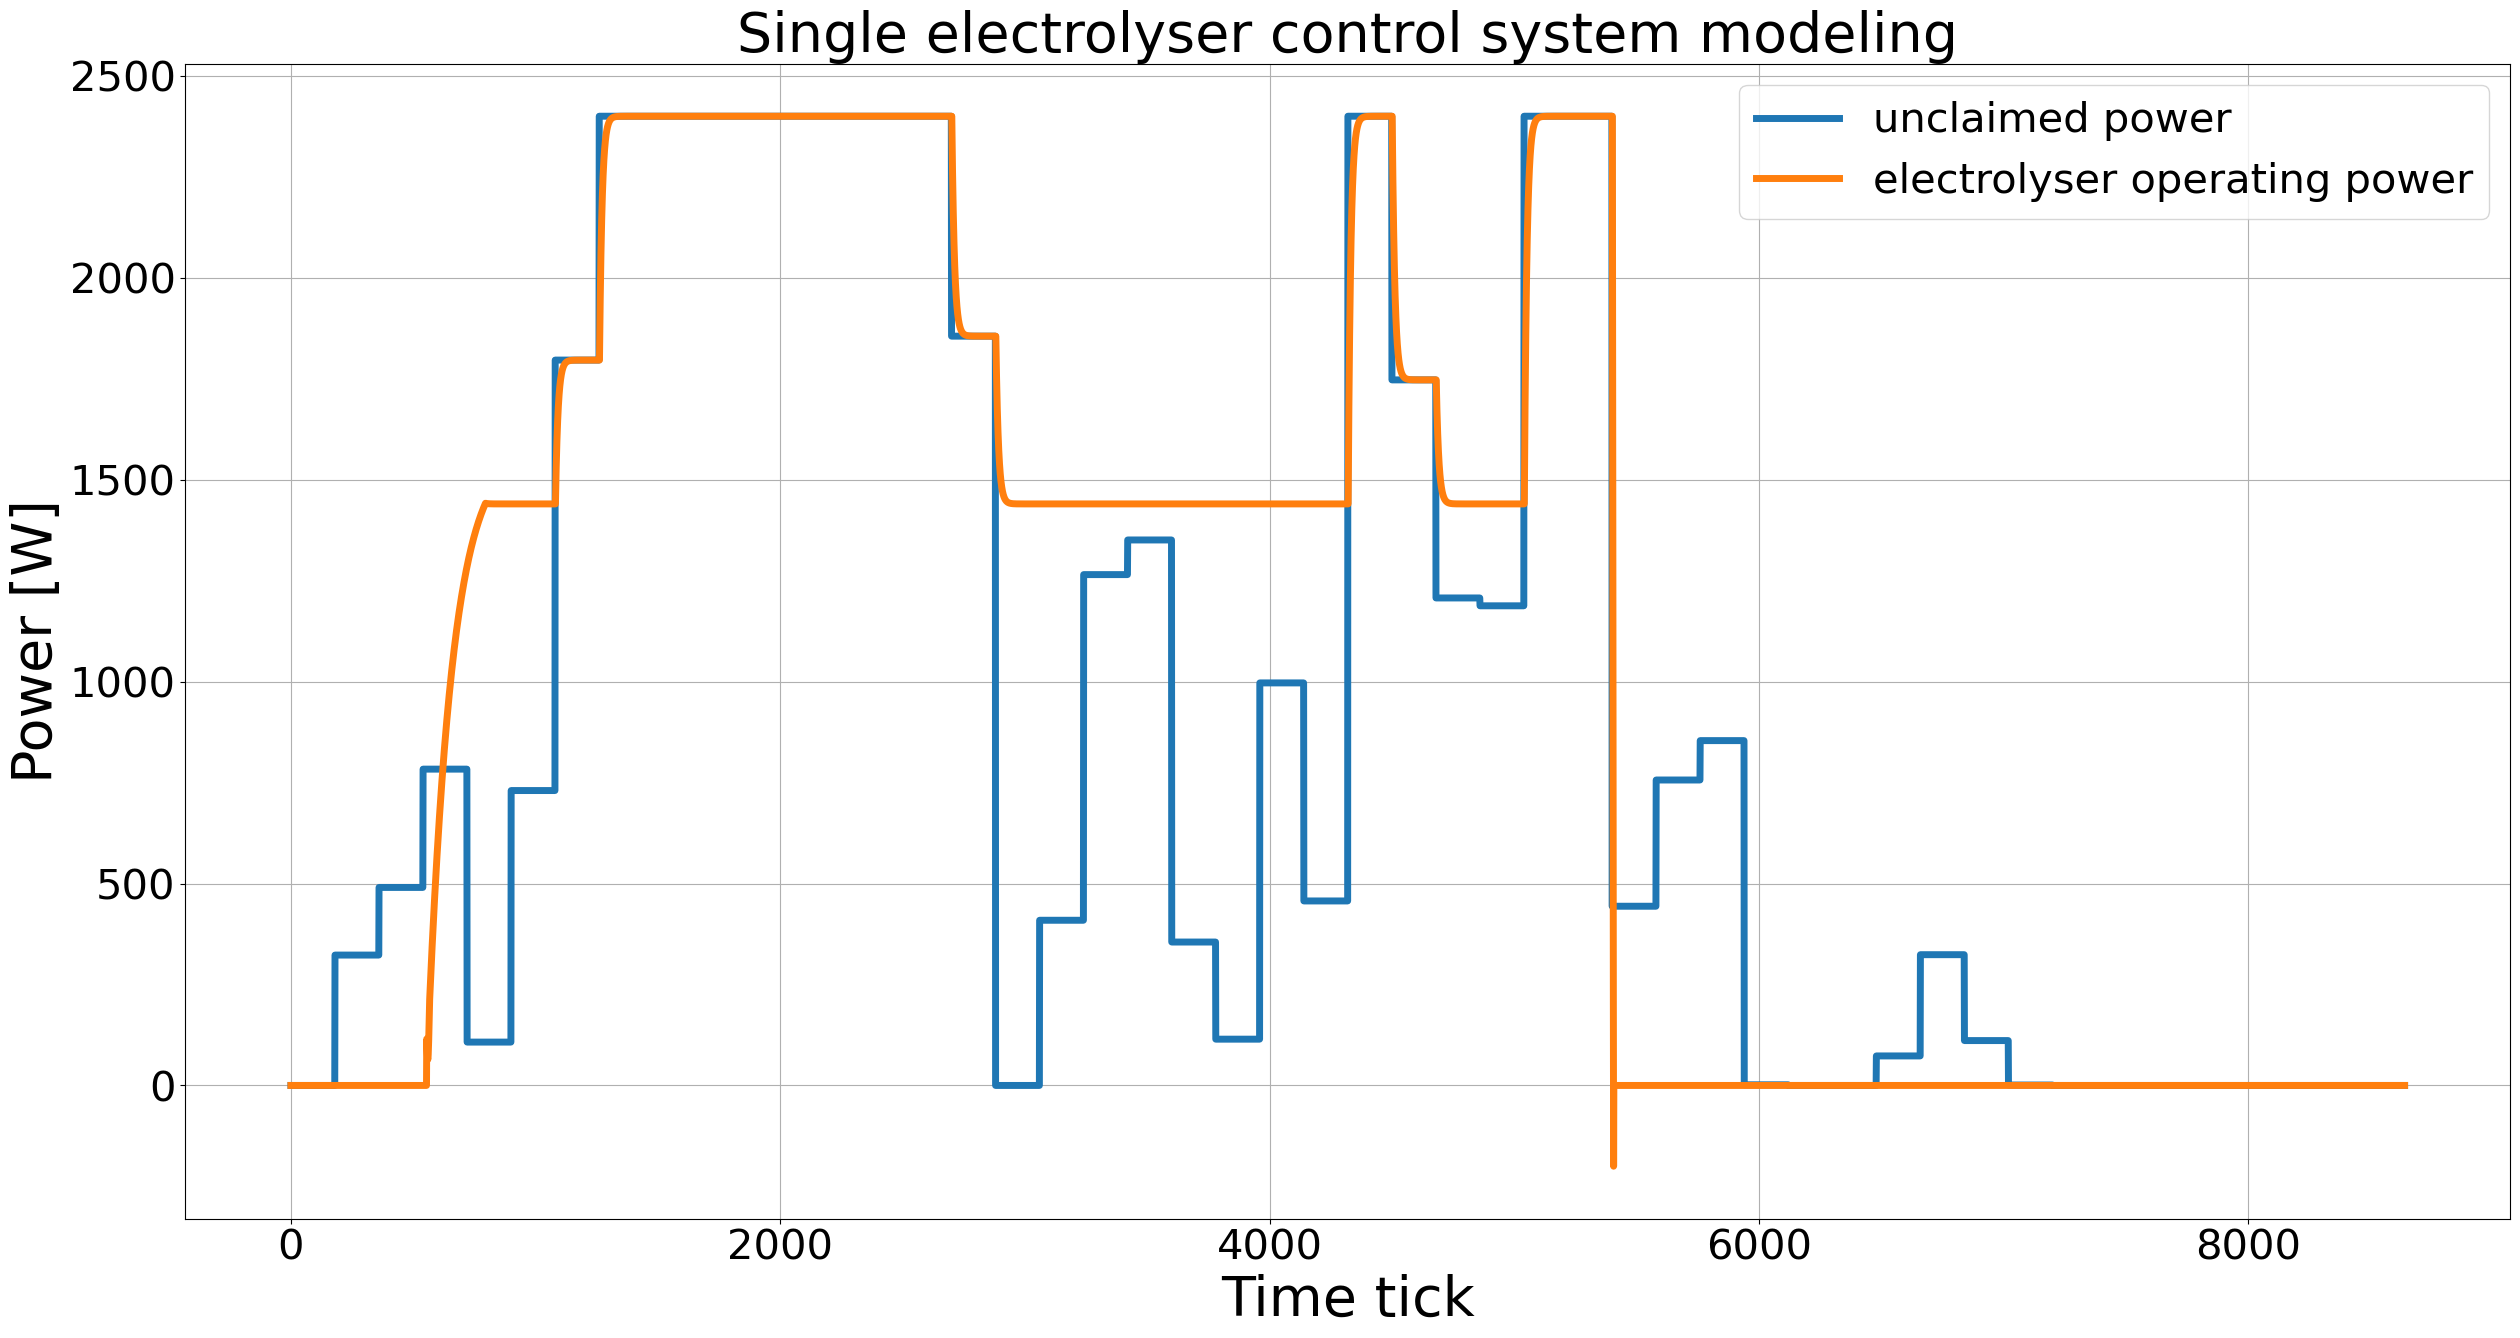

In [9]:
plt.figure(figsize=(30, 15))
plt.title("Single electrolyser control system modeling", fontsize=40)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.plot(np.clip(np.array(data_on_each_step["reference_signal_plan_first_value"]),
                                   a_min=None,
                                   a_max=2400),
         label='unclaimed power',
         linewidth=5)
plt.plot(data_on_each_step["electrolyser_output_value"],
         label='electrolyser operating power',
         linewidth=5)
plt.xlabel('Time tick', fontsize=40)
plt.ylabel('Power [W]', fontsize=40)
plt.legend(prop={'size': 30})
plt.grid(visible=True)

In [10]:
np.sum(np.array(data_on_each_step["reference_signal_plan_first_value"])[:4000]) * 5 / 3600000

11.48798373888889

In [11]:
2 * 3600 * 0.6 * 2400 / 3600000

2.88

In [12]:
def calc_metrics(reference_signal, actual_signal, simulation_discretization_interval):
    error = reference_signal - actual_signal
    RMSE = np.sqrt(np.mean(np.power(error, 2)))
    N = np.absolute(error)
    D = np.absolute(reference_signal) + np.absolute(actual_signal)
    N = N[D != 0]
    D = D[D != 0]
    SMAPE = 0
    MAE = 0
    if N.size > 0:
        SMAPE = np.mean(np.divide(N, D))
        MAE = np.mean(N)
    energy_loss = (np.sum(reference_signal) -
                   np.sum(actual_signal)) * simulation_discretization_interval # W * sec
    energy_loss = energy_loss / 3600000 # kW * h
    bad_episode_label = 1 if SMAPE > 0.5 else 0
    return [RMSE, MAE, SMAPE, energy_loss, bad_episode_label]

In [13]:
reference_signal = np.clip(np.array(data_on_each_step["reference_signal_plan_first_value"]),
                                   a_min=None,
                                   a_max=2400)
actual_signal = np.array(data_on_each_step["electrolyser_output_value"])

[RMSE, MAE, SMAPE, energy_loss, bad_episode_label] = calc_metrics(reference_signal,
                                                                  actual_signal,
                                                                  simulation_discretization_interval)

In [14]:
energy_loss # -4.12292 не хорошо, если батарея имеет 3.3 кВтч

-1.4117824510084414

# Simulate many episodes

In [15]:
def simulate_several_episodes(h2_power_data_frame):
    elec_max_power = 2400
    RMSE_array = []
    MAE_array = []
    SMAPE_array = []
    episodes_start_timestamps = []
    energy_loss_array = []
    simulation_discretization_interval = 5
    hours_in_episode = 12
    simulation_steps_number = hours_in_episode * 3600 // simulation_discretization_interval
    minutes_in_day = 24 * 60
    raw_indx = 600
    episode_start_timestamp = h2_power_data_frame['timestamp'][raw_indx]
    last_timestamp_in_data = h2_power_data_frame.iloc[-2000]["timestamp"]
    while episode_start_timestamp < last_timestamp_in_data:
        plant = elec.Electrolyser(ID = 0, delta_t = simulation_discretization_interval)
        controller = ctr.ControllerElectrolyser()
        reference_signal_generator = upp.UnclaimedPowerSourceHistoryBased(h2_power_data_frame,
                                                                          plan_type = upp.PlanTypes.IDEAL)
        reference_signal_generator.setup_simulation_episode(episode_start_timestamp,
                                                            hours_in_episode)
        data_on_each_step = simulate_episode(plant,
                                             controller,
                                             reference_signal_generator,
                                             simulation_discretization_interval,
                                             simulation_steps_number)
        reference_signal = np.clip(np.array(data_on_each_step["reference_signal_plan_first_value"]),
                                   a_min=None,
                                   a_max=elec_max_power)
        actual_signal = np.array(data_on_each_step["electrolyser_output_value"])
        [RMSE, MAE, SMAPE, energy_loss, bad_episode_label] = calc_metrics(reference_signal,
                                                                          actual_signal,
                                                                          simulation_discretization_interval)
        episodes_start_timestamps.append(episode_start_timestamp)
        RMSE_array.append(RMSE)
        MAE_array.append(MAE)
        SMAPE_array.append(SMAPE)
        energy_loss_array.append(energy_loss)
        raw_indx += minutes_in_day
        episode_start_timestamp = h2_power_data_frame['timestamp'][raw_indx]
    return [RMSE_array, MAE_array, SMAPE_array, episodes_start_timestamps, energy_loss_array]

In [16]:
[RMSE_array,
 MAE_array,
 SMAPE_array,
 episodes_start_timestamps,
 energy_loss_array] = simulate_several_episodes(h2_power_data_frame)

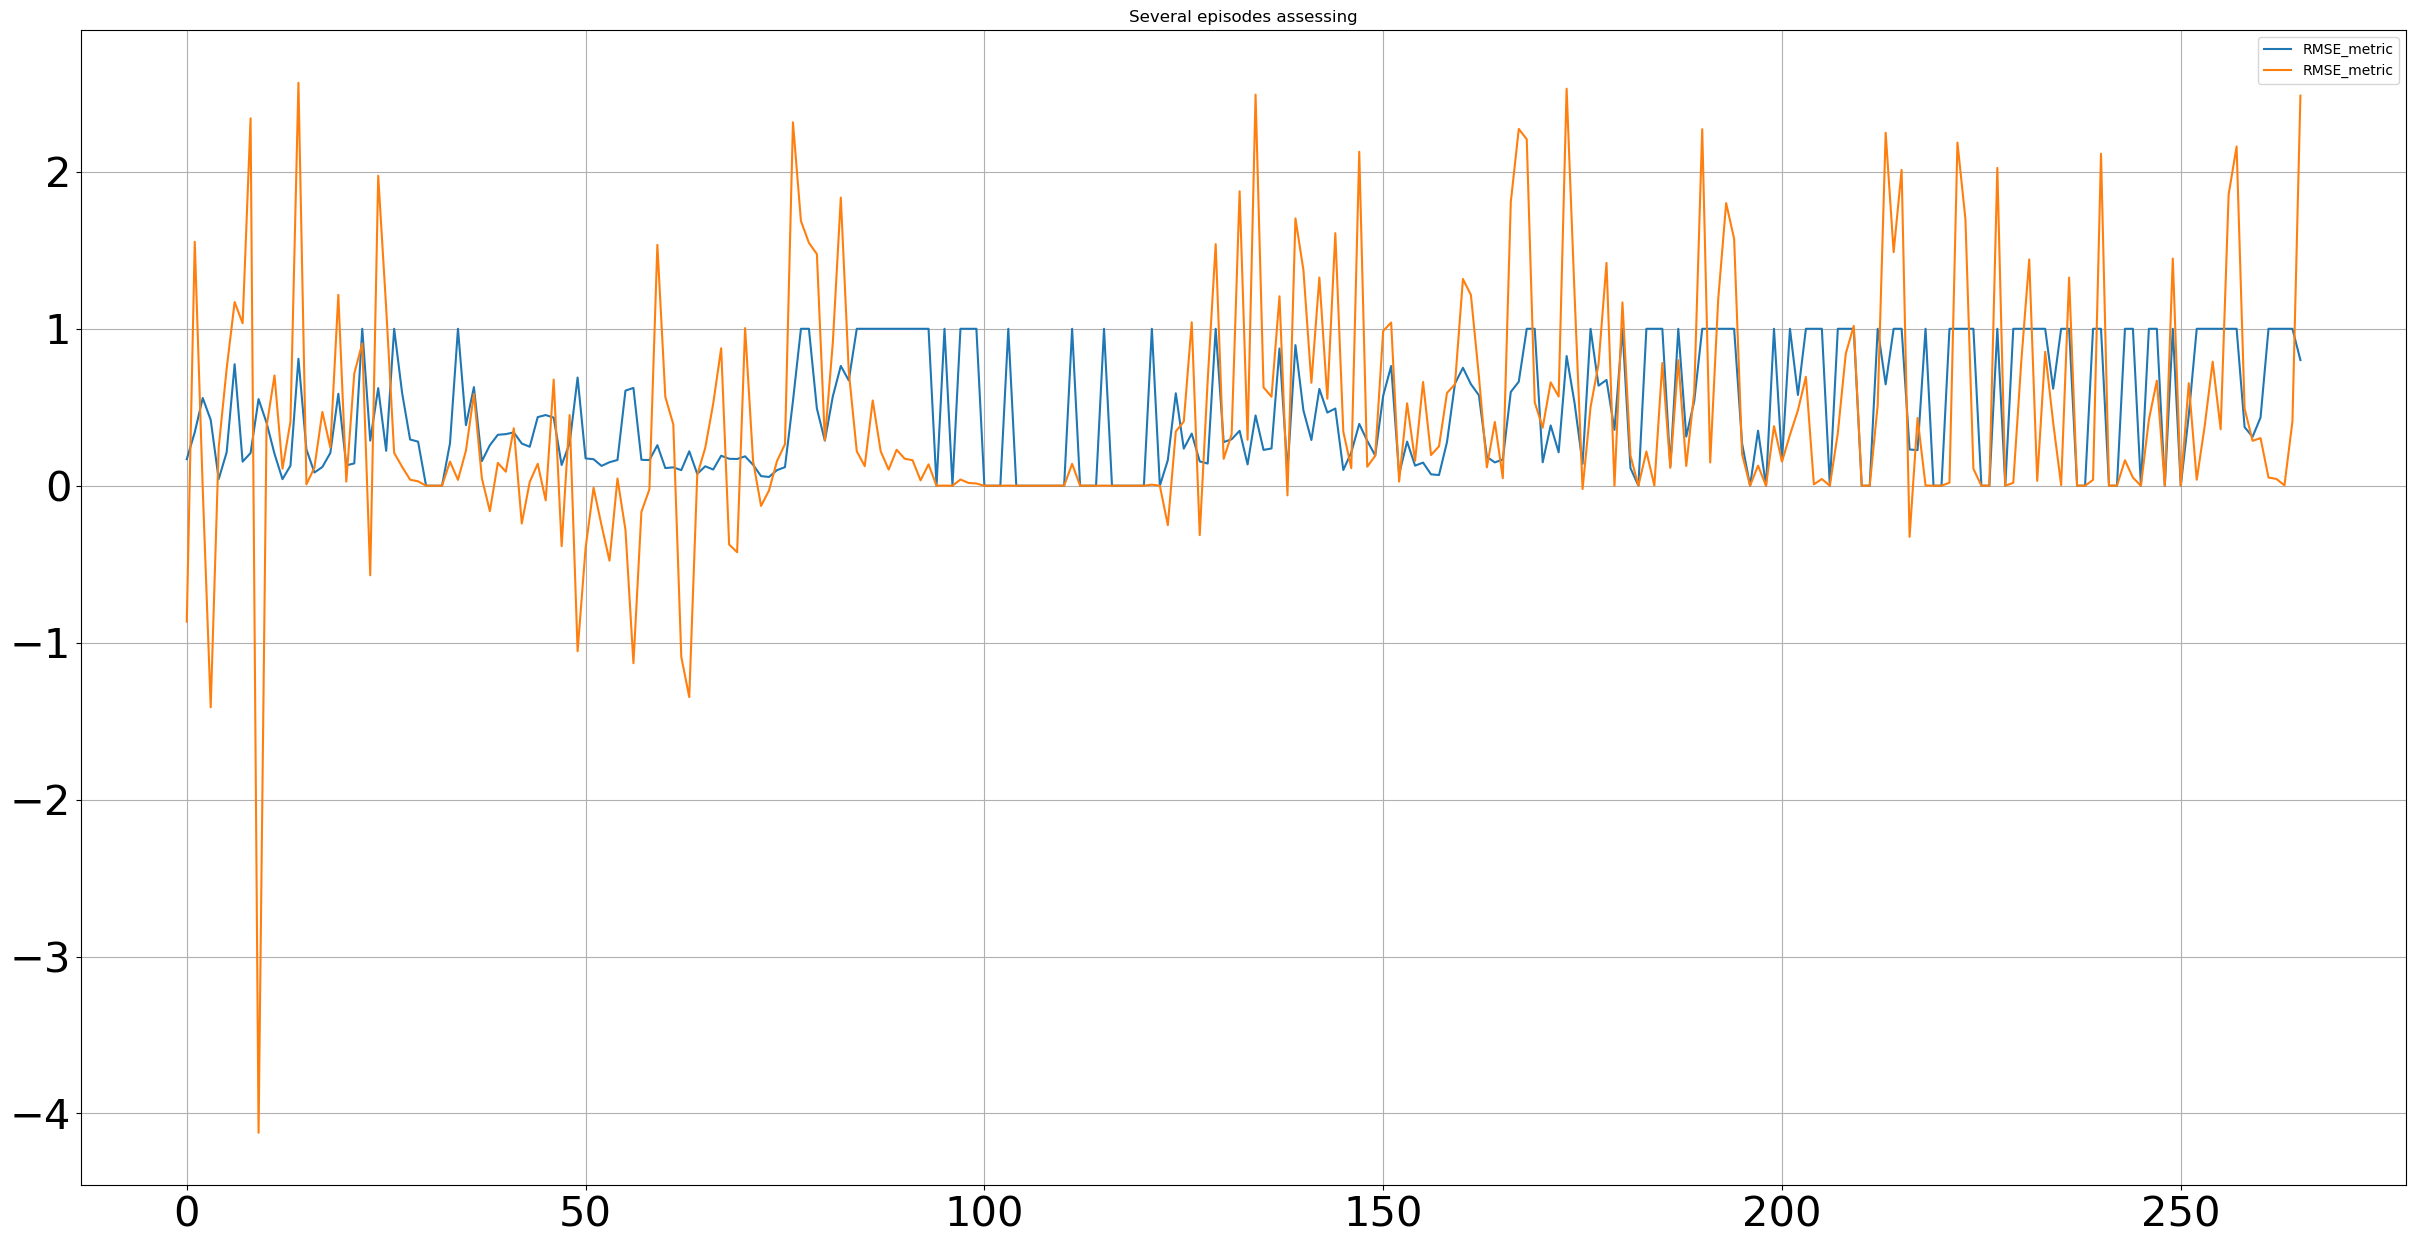

In [17]:
plt.figure(figsize=(30, 15))
plt.title("Several episodes assessing")
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.plot(SMAPE_array, label='SMAPE_array')
plt.plot(energy_loss_array, label='energy_loss_array')
plt.legend()
plt.grid(visible=True)

In [18]:
np.mean(np.array(energy_loss_array)[40:])

0.46671119956408014

In [20]:
bad_episode = episodes_start_timestamps[np.argmin(np.array(energy_loss_array))]

In [21]:
bad_episode

Timestamp('2022-05-10 06:47:00+0000', tz='UTC')